# Analysez des données de systèmes éducatifs

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
data = pd.read_csv('data/interim/EdStatsData.csv', sep=',')
data = data.set_index('Country Name')

data.rename(columns={
    'Enrolment in secondary education, both sexes (number)': 'enrolment_secondary',
    'Gross enrolment ratio, secondary, both sexes (%)': 'enrolment_ratio_secondary',
    'Gross enrolment ratio, upper secondary, both sexes (%)': 'enrolment_ratio_upper_secondary',
    'Population of the official age for tertiary education, both sexes (number)': 'pop_age_tertiary',
    'Population of the official age for upper secondary education, both sexes (number)': 'pop_age_upper_secondary',
    'Population, age 15, total': 'pop_age_15',
    'Population, age 16, total': 'pop_age_16',
    'Population, age 17, total': 'pop_age_17',
    'Population, age 18, total': 'pop_age_18',
    'Population, age 19, total': 'pop_age_19',
    'Population, age 20, total': 'pop_age_20',
    'Population, age 21, total': 'pop_age_21',
    'Population, age 22, total': 'pop_age_22',
    'Population, age 23, total': 'pop_age_23',
    'Population, age 24, total': 'pop_age_24',
}, inplace=True)

## Identification des indicateurs redondants d'un point de vue statistique

In [15]:
# Calculez une matrice de corrélation entre l’ensemble des indicateurs en utilisant la méthode de Pearson puis de Spearman

# Méthode de Pearson
pearson_matrix = data.corr()
pearson_matrix

,enrolment_secondary,enrolment_ratio_secondary,enrolment_ratio_upper_secondary,pop_age_tertiary,pop_age_upper_secondary,pop_age_15,pop_age_16,pop_age_17,pop_age_18,pop_age_19,pop_age_20,pop_age_21,pop_age_22,pop_age_23,pop_age_24
enrolment_secondary,1.000000,0.012615,-0.004970,0.988561,0.978183,0.991818,0.992229,0.992580,0.992697,0.992349,0.991599,0.990426,0.989340,0.988824,0.988792
enrolment_ratio_secondary,0.012615,1.000000,0.957192,-0.026543,-0.051682,-0.054435,-0.051695,-0.048627,-0.045071,-0.041259,-0.037573,-0.033925,-0.030586,-0.027677,-0.025035
enrolment_ratio_upper_secondary,-0.004970,0.957192,1.000000,-0.038968,-0.060718,-0.063313,-0.060943,-0.058246,-0.055067,-0.051624,-0.048279,-0.044956,-0.041905,-0.039245,-0.036830
pop_age_tertiary,0.988561,-0.026543,-0.038968,1.000000,0.960534,0.991250,0.992293,0.993733,0.995621,0.997399,0.998616,0.999392,0.999696,0.999724,0.999644
pop_age_upper_secondary,0.978183,-0.051682,-0.060718,0.960534,1.000000,0.985803,0.984973,0.983343,0.980379,0.976350,0.972137,0.967536,0.963626,0.961195,0.959871
pop_age_15,0.991818,-0.054435,-0.063313,0.991250,0.985803,1.000000,0.999956,0.999758,0.999186,0.998069,0.996572,0.994663,0.992855,0.991634,0.990904
pop_age_16,0.992229,-0.051695,-0.060943,0.992293,0.984973,0.999956,1.000000,0.999918,0.999503,0.998563,0.997233,0.995488,0.993808,0.992664,0.991973
pop_age_17,0.992580,-0.048627,-0.058246,0.993733,0.983343,0.999758,0.999918,1.000000,0.999822,0.999157,0.998084,0.996592,0.995112,0.994086,0.993457
pop_age_18,0.992697,-0.045071,-0.055067,0.995621,0.980379,0.999186,0.999503,0.999822,1.000000,0.999753,0.999071,0.997967,0.996792,0.995947,0.995413
pop_age_19,0.992349,-0.041259,-0.051624,0.997399,0.976350,0.998069,0.998563,0.999157,0.999753,1.000000,0.999782,0.999138,0.998325,0.997695,0.997276


In [16]:
# Méthode de Spearman

spearman_matrix = data.corr('spearman')
spearman_matrix

,enrolment_secondary,enrolment_ratio_secondary,enrolment_ratio_upper_secondary,pop_age_tertiary,pop_age_upper_secondary,pop_age_15,pop_age_16,pop_age_17,pop_age_18,pop_age_19,pop_age_20,pop_age_21,pop_age_22,pop_age_23,pop_age_24
enrolment_secondary,1.000000,0.011281,0.021965,0.971317,0.957839,0.955572,0.958386,0.960560,0.963103,0.965160,0.966781,0.969448,0.970786,0.972522,0.973789
enrolment_ratio_secondary,0.011281,1.000000,0.951978,-0.160533,-0.198384,-0.226941,-0.217849,-0.210309,-0.201872,-0.192457,-0.185487,-0.172199,-0.163544,-0.155093,-0.146699
enrolment_ratio_upper_secondary,0.021965,0.951978,1.000000,-0.147952,-0.184592,-0.215502,-0.205783,-0.198368,-0.188876,-0.179427,-0.171742,-0.157688,-0.147891,-0.139438,-0.131390
pop_age_tertiary,0.971317,-0.160533,-0.147952,1.000000,0.987349,0.994099,0.995269,0.996323,0.997172,0.997907,0.998230,0.998418,0.998327,0.998228,0.997743
pop_age_upper_secondary,0.957839,-0.198384,-0.184592,0.987349,1.000000,0.988005,0.988643,0.988938,0.988680,0.988103,0.987689,0.987090,0.985967,0.985889,0.985232
pop_age_15,0.955572,-0.226941,-0.215502,0.994099,0.988005,1.000000,0.999761,0.999356,0.998716,0.997761,0.996734,0.995127,0.993701,0.992613,0.991446
pop_age_16,0.958386,-0.217849,-0.205783,0.995269,0.988643,0.999761,1.000000,0.999765,0.999288,0.998543,0.997706,0.996315,0.995037,0.994057,0.992942
pop_age_17,0.960560,-0.210309,-0.198368,0.996323,0.988938,0.999356,0.999765,1.000000,0.999743,0.999220,0.998541,0.997352,0.996251,0.995385,0.994319
pop_age_18,0.963103,-0.201872,-0.188876,0.997172,0.988680,0.998716,0.999288,0.999743,1.000000,0.999708,0.999241,0.998307,0.997407,0.996660,0.995642
pop_age_19,0.965160,-0.192457,-0.179427,0.997907,0.988103,0.997761,0.998543,0.999220,0.999708,1.000000,0.999778,0.999179,0.998500,0.997893,0.996957


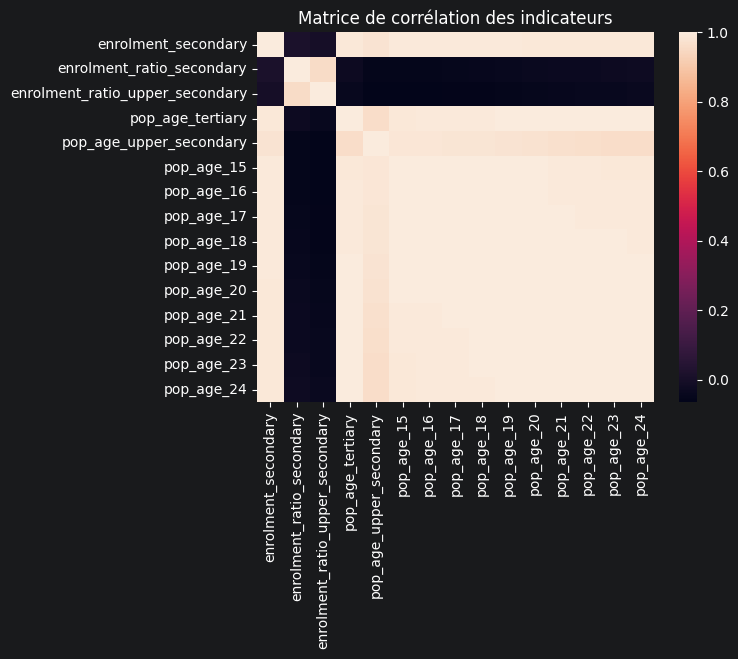

In [17]:
sns.heatmap(data=pearson_matrix)
plt.title('Matrice de corrélation des indicateurs')
plt.show()

<Axes: >

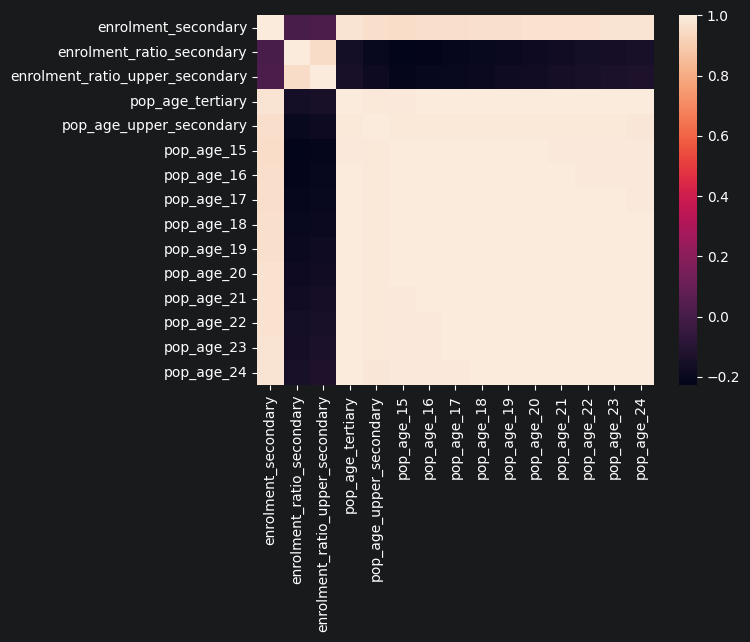

In [18]:
sns.heatmap(data=spearman_matrix)

On remarque sur la heatmap que "Gross enrolment ratio, secondary, both sexes" et "Gross enrolment ratio, upper secondary, both sexes" sont fortément corrélé (même couleurs),
l'indicateur "upper secondary" représente le lycée alors que "secondary" représente collège et lycée., vu que l'ont cherche a cibler Lycée et Université dans le cadre de notre Edtech, je vais supprimer l'indictauer secondary qui n'as pas de valeur ajoutée.

In [19]:
data.drop(columns='enrolment_ratio_secondary', inplace=True)

De la même manière, grâce à la heatmap, on remarque un gros carée blanc en bas à droite de la carte. Tous les indicateurs d'ages sont fortement corrélés.
Je vais fusionner les tranches d'âge afin de ne garder qu'un seul indicateur age_15_24 qui contizent la somme des indicateurs d'ages.


In [20]:
data['age_15_24'] = data.iloc[:, -10:].sum(axis=1)
cols_a_supprimer = data.columns[-11:-1]
data.drop(columns=cols_a_supprimer, inplace=True)

<Axes: >

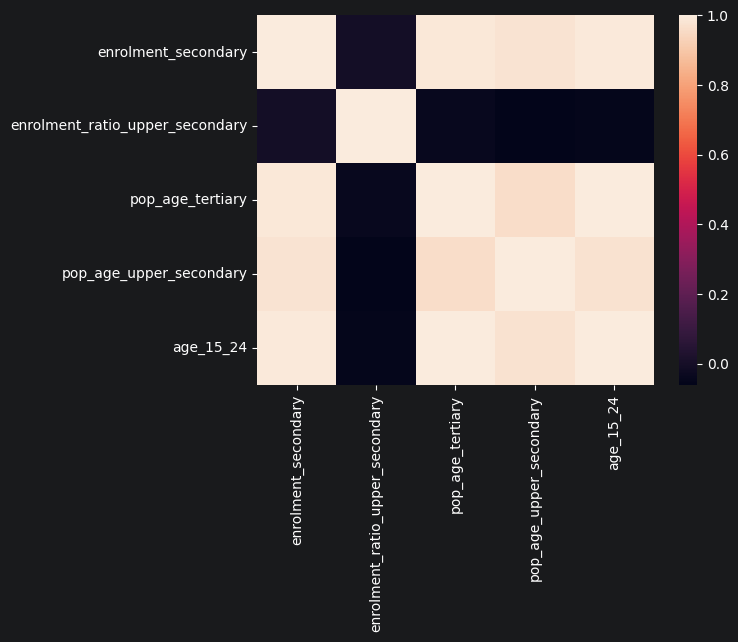

In [21]:
sns.heatmap(data=data.corr(method='pearson'))

On remarque que le "Gross enrolment ratio, upper secondary, both sexes (%) se démarque des autre il est donc fortement décorrélé des autres indicateurs.
En revanche tout les autres sont très corrélé.

Par exemple "Population of the official age for tertiary education" est forcément très corrélé avec age_15_24 ce qui semble logique puisque les population vont se retrouver dans les 2 catégories.

De mon point de vue age_24_25 est important pour nous, car il détermine le public cible de notre marché.
Je décide donc de ne garder que :
- age_24_25
- enrolment_ratio_upper_secondary


In [22]:
final_data = data[['enrolment_ratio_upper_secondary', 'age_15_24']]

## Analysez vos indicateurs restants et formulez une liste de pays pertinents pour l'implantation d'Academy

In [23]:
# Choisissez un indicateur (celui que vous voulez) et calculez ses statistiques descriptives basiques puis tracez sa distribution.
def describe_indicator(data, indicator_label):
    print(data.describe())

    sns.displot(data)

    plt.xlabel(indicator_label, fontsize=12)
    plt.ylabel("Nombre de pays", fontsize=12)

    plt.show()

Index(['enrolment_ratio_upper_secondary', 'age_15_24'], dtype='str')
count    160.000000
mean      73.697927
std       33.861892
min        7.469405
25%       42.242105
50%       80.480159
75%       95.564898
max      178.556668
Name: enrolment_ratio_upper_secondary, dtype: float64


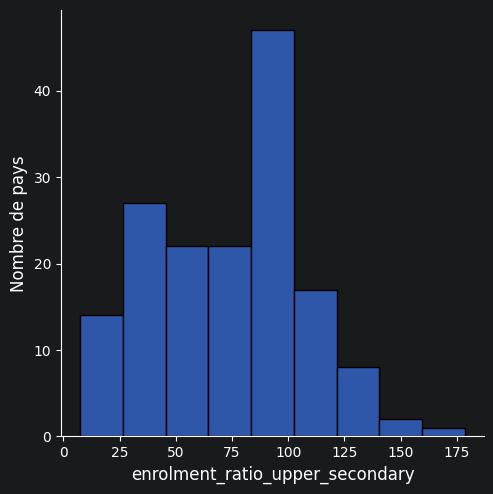

count    1.800000e+02
mean     6.715297e+06
std      2.443866e+07
min      1.378360e+04
25%      5.036711e+05
50%      1.319282e+06
75%      4.961708e+06
max      2.395948e+08
Name: age_15_24, dtype: float64


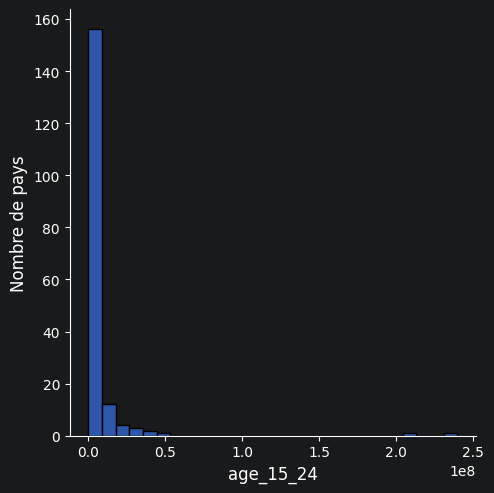

In [24]:
print(final_data.columns)
for col in final_data.columns:
    describe_indicator(final_data[col], col)

### Analyse de l'indicateur "age_15_24" :

La distribution déformée par les outliners

In [25]:
final_data.sort_values('age_15_24', ascending=False).head(5)

,enrolment_ratio_upper_secondary,age_15_24
Country Name,,
India,57.534580,239594829.0
China,81.335791,210099514.8
United States,90.821086,45246251.8
Indonesia,71.517016,41974836.2
Pakistan,30.103098,39171669.0


En effet la Chine et l'Inde écrasent les autres pays.

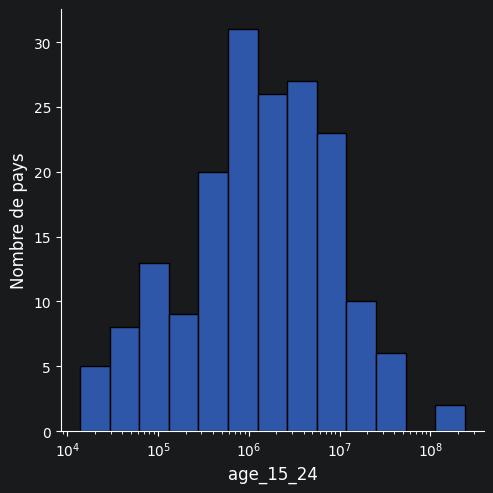

In [26]:
# On ajoute log_scale pour retrouver une distribution moins affectée par ces deux outliners
sns.displot(data['age_15_24'], log_scale=True)

plt.xlabel('age_15_24', fontsize=12)
plt.ylabel("Nombre de pays", fontsize=12)

plt.show()

De cette manière on retrouve une distribution normale.

### Analyse de l'indicateur "Gross enrolment ratio, upper secondary, both sexes (%)" :

La médiane à 80.48% nous indique que 50% des pays atteigne 80% de scolarisation dans Lycée.
Ces pays sont très intéréssant pour notre Edtech.


In [27]:
# Proposez une méthode quantitative, sur la base des indicateurs, pour sélectionner des pays et répondre à la demande de Mark

# Je vais essayer de prendre les 20 premiers de chaque indicateur et croiser les listes pour voir si des pays se démarquent
final_data.sort_values('age_15_24', ascending=False, inplace=True)
most_populated_countries = final_data.iloc[0:20]

final_data.sort_values('enrolment_ratio_upper_secondary', ascending=False, inplace=True)
most_gross_enrolment_countries = final_data.iloc[0:20]

selected_countries = set(most_populated_countries.index.tolist()) & set(most_gross_enrolment_countries.index.tolist())
print(f'Nombre de pays : {len(selected_countries)}')


Nombre de pays : 0


Aucun pays ne ressort dans le top 20 selon les indicateurs de population et de taux de scolarisation.

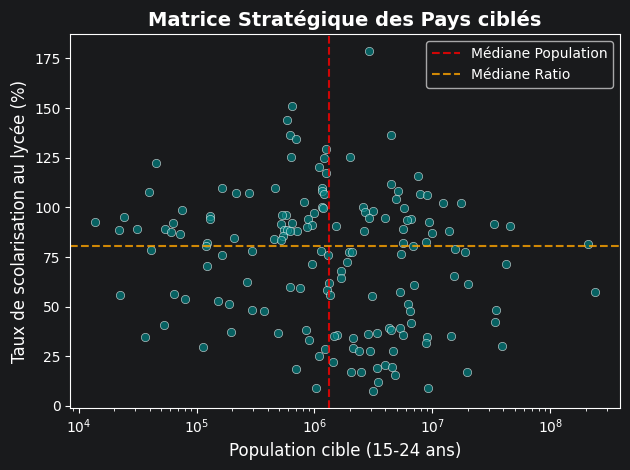

In [28]:
sns.scatterplot(data=final_data,
                x='age_15_24',
                y='enrolment_ratio_upper_secondary',
                alpha=0.7,
                color='teal')

# Echelle log pour eviter que le graphique soit écrasé a cause des outliner Inde et Chine sur l'indicateur age_15_24
plt.xscale('log')

# Affichage des mediane pour diviser les graphiques en 4 sections
median_pop = final_data['age_15_24'].median()
median_ratio = final_data['enrolment_ratio_upper_secondary'].median()
plt.axvline(median_pop, color='red', linestyle='--', alpha=0.8, label='Médiane Population')
plt.axhline(median_ratio, color='orange', linestyle='--', alpha=0.8, label='Médiane Ratio')

plt.title("Matrice Stratégique des Pays ciblés", fontsize=14, fontweight='bold')
plt.xlabel("Population cible (15-24 ans)", fontsize=12)
plt.ylabel("Taux de scolarisation au lycée (%)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()


Visuellement ici, on voit 4 sections :

La section en haut à gauche : Pays fortement scolarisé avec une faible population jeune.
Section en bas à gauche : Pays Faiblement scolarisé avec une faible population jeune.
Section en bas a droite : Pays faiblement scolarisé avec une forte population jeune.
Section en haut à gauche : Pays Fortement scolarisé à forte population jeune. (Notre cible prioritaire)

In [29]:
most_interesting_countries = final_data.loc[(final_data['age_15_24'] > median_pop) & (final_data['enrolment_ratio_upper_secondary'] > median_ratio)]
print(f'Nombre de pays intéréssant : {len(most_interesting_countries)}')

Nombre de pays intéréssant : 31


In [30]:
from sklearn.preprocessing import MinMaxScaler

# On doit normaliser les colonnes, car on ne peut pas fusionner des populations et des %age d'inscription.
scaler = MinMaxScaler()

columns_to_normalize = ['age_15_24', 'enrolment_ratio_upper_secondary']
most_interesting_countries[['population_score', 'enrolment_ratio_score']] = scaler.fit_transform(most_interesting_countries[columns_to_normalize])
most_interesting_countries['global_score'] = (most_interesting_countries['population_score'] + most_interesting_countries['enrolment_ratio_score']) / 2

# Tri par score décroissant
top_pays_finaux = most_interesting_countries.sort_values('global_score', ascending=False)

print(f'Nombre de pays sélectionnés : {len(top_pays_finaux)}')
# Top 20
top_pays_finaux[:10]


Nombre de pays sélectionnés : 31


,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score
Country Name,,,,,
China,81.335791,210099514.8,1.000000,0.006906,0.503453
Australia,178.556668,2920804.4,0.006743,1.000000,0.503372
Spain,136.442825,4436945.4,0.014012,0.569815,0.291913
Netherlands,125.555078,2002184.0,0.002339,0.458598,0.230469
France,115.591806,7588616.6,0.029122,0.356825,0.192974
Canada,111.744696,4459604.4,0.014121,0.317528,0.165824
United States,90.821086,45246251.8,0.209660,0.103797,0.156729
Saudi Arabia,108.314159,5119918.2,0.017286,0.282486,0.149886
United Kingdom,106.872313,7923198.0,0.030726,0.267757,0.149242


In [31]:
imported_series = pd.read_csv('data/raw/EdStatsSeries.csv', sep=',')
imported_stats = pd.read_csv('data/raw/EdStatsData.csv', sep=',')

In [32]:
series_code_topic_infrastructure = imported_series.loc[imported_series['Topic'] == 'Infrastructure: Communications']

indicators_infrastructure = imported_stats.loc[(imported_stats['Indicator Code'].isin(series_code_topic_infrastructure['Series Code'])) & (imported_stats['Country Name'].isin(top_pays_finaux.index.tolist()))]

import numpy as np
years = np.concatenate((np.arange(1970, 2010, 1), np.arange(2020, 2105, 5)))
cols = [str(col) for col in years]

indicators_infrastructure.drop(columns=cols, inplace=True)
indicators_infrastructure.drop(columns='2017', inplace=True)
indicators_infrastructure.drop(columns='Unnamed: 69', inplace=True)

In [33]:
indicators_infrastructure.set_index(['Country Name', 'Indicator Name']).isna().sum(axis=1)

# On a aucune donnée pour l'indicateur Personal computers (per 100 people) donc on ne garde pas cet indicateur
indicators_infrastructure = indicators_infrastructure[indicators_infrastructure['Indicator Name'] == 'Internet users (per 100 people)']

indicators_infrastructure


,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016
118655,Argentina,ARG,Internet users (per 100 people),IT.NET.USER.P2,45.00,51.000000,55.800000,59.900000,64.700000,68.043064,70.150764
129650,Australia,AUS,Internet users (per 100 people),IT.NET.USER.P2,76.00,79.487698,79.000000,83.453497,84.000000,84.560519,88.238658
188290,Brazil,BRA,Internet users (per 100 people),IT.NET.USER.P2,40.65,45.690000,48.560000,51.040000,54.551002,58.327952,59.682747
221275,Canada,CAN,Internet users (per 100 people),IT.NET.USER.P2,80.30,83.000000,83.000000,85.800000,87.120000,88.470000,89.840000
239600,Chile,CHL,Internet users (per 100 people),IT.NET.USER.P2,45.00,52.249607,55.050000,58.000000,61.110000,64.289000,66.010000
243265,China,CHN,Internet users (per 100 people),IT.NET.USER.P2,34.30,38.300000,42.300117,45.800000,47.900000,50.300000,53.200000
246930,Colombia,COL,Internet users (per 100 people),IT.NET.USER.P2,36.50,40.350916,48.980000,51.700000,52.570000,55.904973,58.136494
272585,Cuba,CUB,Internet users (per 100 people),IT.NET.USER.P2,15.90,16.017291,21.200000,27.930000,29.070184,37.305097,38.765867
301905,Ecuador,ECU,Internet users (per 100 people),IT.NET.USER.P2,29.03,31.366808,35.135146,40.279122,45.590391,48.940434,54.062925
338555,France,FRA,Internet users (per 100 people),IT.NET.USER.P2,77.28,77.819999,81.440000,81.919800,83.750000,84.694500,85.622200


In [34]:
years = ['2010', '2011', '2012', '2013', '2014', '2015', '2016']

# On ne garde que le max, la couverture d'internet ne pouvant pas (sauf catastrophe) diminuer
indicators_infrastructure['max_internet'] = indicators_infrastructure[years].max(axis=1)

# On ajoute à notre tableau des pays les plus intéréssant le max(internet_per_100)
most_interesting_countries['internet_per_100'] = indicators_infrastructure.set_index('Country Name')['max_internet']

most_interesting_countries

,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score,internet_per_100
Country Name,,,,,,
Australia,178.556668,2920804.4,0.006743,1.000000,0.503372,88.238658
Spain,136.442825,4436945.4,0.014012,0.569815,0.291913,80.561333
Netherlands,125.555078,2002184.0,0.002339,0.458598,0.230469,93.956400
France,115.591806,7588616.6,0.029122,0.356825,0.192974,85.622200
Canada,111.744696,4459604.4,0.014121,0.317528,0.165824,89.840000
Saudi Arabia,108.314159,5119918.2,0.017286,0.282486,0.149886,73.750904
United Kingdom,106.872313,7923198.0,0.030726,0.267757,0.149242,94.775801
Germany,105.991877,9080370.2,0.036274,0.258764,0.147519,89.647101
Poland,104.092271,4908971.6,0.016275,0.239360,0.127817,73.300700


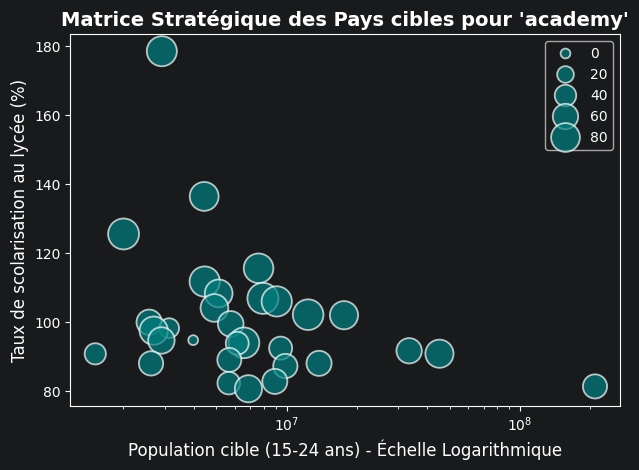

In [35]:
sns.scatterplot(data=most_interesting_countries,
                x='age_15_24',
                y='enrolment_ratio_upper_secondary',
                size='internet_per_100',
                sizes=(50, 500),
                alpha=0.7,
                color='teal')

# Echelle log pour eviter que le graphique soit écrasé a cause des outliner Inde et Chine sur l'indicateur age_15_24
plt.xscale('log')

plt.title("Matrice Stratégique des Pays cibles pour 'academy'", fontsize=14, fontweight='bold')
plt.xlabel("Population cible (15-24 ans) - Échelle Logarithmique", fontsize=12)
plt.ylabel("Taux de scolarisation au lycée (%)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

Le résultat n'est pas très visuel la quasi totalité des pays ayant la même couverture internet (sauf outliners)

In [36]:
print(most_interesting_countries['internet_per_100'].describe())

most_interesting_countries

# Malgré tout cela nous permet de voir qu'on a un outliner a 0, la Corée du nord. On ne garde que les pays ayant une couverture intéréssante (50% de la population)
#most_interesting_countries = most_interesting_countries.loc[most_interesting_countries['internet_per_100'] > 50]#

count    31.000000
mean     65.847452
std      21.538726
min       0.000000
25%      53.600000
50%      66.010000
75%      83.091766
max      94.775801
Name: internet_per_100, dtype: float64


,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score,internet_per_100
Country Name,,,,,,
Australia,178.556668,2920804.4,0.006743,1.000000,0.503372,88.238658
Spain,136.442825,4436945.4,0.014012,0.569815,0.291913,80.561333
Netherlands,125.555078,2002184.0,0.002339,0.458598,0.230469,93.956400
France,115.591806,7588616.6,0.029122,0.356825,0.192974,85.622200
Canada,111.744696,4459604.4,0.014121,0.317528,0.165824,89.840000
Saudi Arabia,108.314159,5119918.2,0.017286,0.282486,0.149886,73.750904
United Kingdom,106.872313,7923198.0,0.030726,0.267757,0.149242,94.775801
Germany,105.991877,9080370.2,0.036274,0.258764,0.147519,89.647101
Poland,104.092271,4908971.6,0.016275,0.239360,0.127817,73.300700


In [37]:
# On recalcule la moyenne pondérée avec ce nouvel indicateur
most_interesting_countries['internet_per_100'] = scaler.fit_transform(most_interesting_countries[['internet_per_100']])
most_interesting_countries['global_score'] = (most_interesting_countries['population_score'] + most_interesting_countries['enrolment_ratio_score'] + most_interesting_countries['internet_per_100']) / 3

# Tri par score global décroissant
top_pays_finaux = most_interesting_countries.sort_values('global_score', ascending=False)

print(f'Nombre de pays sélectionnés : {len(top_pays_finaux)}')

Nombre de pays sélectionnés : 31


In [39]:
most_interesting_countries.to_csv('./data/processed/final_data.csv')

Voici ma recommandation finale des pays ou aller essayer de s'implanter :


In [38]:
top_pays_finaux.head(10)

,enrolment_ratio_upper_secondary,age_15_24,population_score,enrolment_ratio_score,global_score,internet_per_100
Country Name,,,,,,
Australia,178.556668,2920804.4,0.006743,1.000000,0.645923,0.931025
China,81.335791,210099514.8,1.000000,0.006906,0.522744,0.561325
Netherlands,125.555078,2002184.0,0.002339,0.458598,0.484097,0.991354
Spain,136.442825,4436945.4,0.014012,0.569815,0.477949,0.850020
United Kingdom,106.872313,7923198.0,0.030726,0.267757,0.432828,1.000000
France,115.591806,7588616.6,0.029122,0.356825,0.429789,0.903418
Canada,111.744696,4459604.4,0.014121,0.317528,0.426523,0.947921
Japan,102.142018,12379060.0,0.052088,0.219438,0.414079,0.970712
Germany,105.991877,9080370.2,0.036274,0.258764,0.413641,0.945886
